enter choice: 2
{'alappuzha': 6.5, 'ernakulam': 4.5, 'kannur': 1.0, 'kochi': 4.0, 'kottayam': 3.0, 'kozhikode': 4.333333333333333, 'malappuram': 3.0, 'palakkad': 4.0, 'thiruvananthapuram': 3.0, 'thrissur': 5.666666666666667}


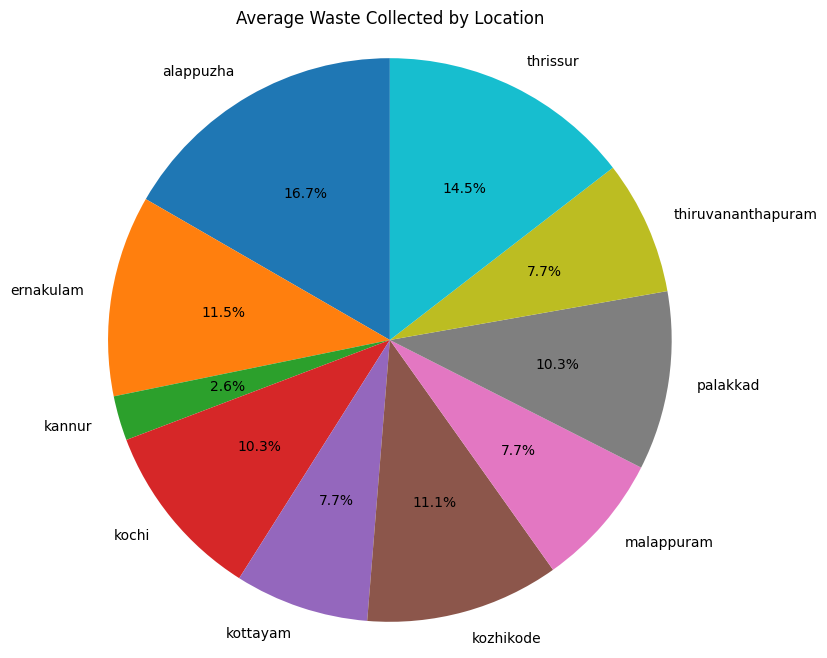

In [87]:
import pandas as pd
import csv
import matplotlib.pyplot as plt

def user():

  # Define field names
  field_names = ['id', 'name', 'location', 'contact', 'collection_date', 'waste_type', 'quantity_collected', 'rate_per_kg']

  # Get user input
  #id = int(input('Enter user id: '))

  name = input('Enter name: ')
  loc = input('Enter location: ')
  ph = input('Enter phone number: ')
  date = input('Enter date (YYYY-MM-DD): ')
  wastetype = input('Enter waste type: ')
  kg = int(input('Enter quantity (kg): '))
  rate = int(input('Enter rate per kg: '))

  #for getting user id automatically without asking from the user
  def get_last_user_id(csv_file_path):
      try:
          with open(csv_file_path, 'r') as csvfile:
              reader = csv.DictReader(csvfile)
              last_row = None
              for row in reader:  # Loop should be inside 'with' block
                  last_row = row  # Store the current row as the last row
              if last_row:
                  return int(last_row['id'])  # Return the ID from the last row
              else:
                  return 0  # Return 0 if the file is empty
      except FileNotFoundError:
          return 0  # Return 0 if the file doesn't exist

  csv_file_path = 'waste.csv'  # Replace with your CSV file path
  last_user_id = get_last_user_id(csv_file_path)
  next_user_id = last_user_id + 1

  # Store data as a single dictionary
  paper_waste_data = {
      'id': next_user_id,
      'name': name.lower(),
      'location': loc.lower(),
      'contact': ph,
      'collection_date': date,
      'waste_type': wastetype.lower(),
      'quantity_collected': kg,
      'rate_per_kg': rate
  }

  '''# Write data to CSV
  with open('waste.csv', 'w', newline='') as csvfile:
      writer = csv.DictWriter(csvfile, fieldnames=field_names)
      writer.writeheader()
      writer.writerow(paper_waste_data)  # Write a single rw'''

  with open('waste.csv', 'a', newline='') as csvfile:
      writer = csv.DictWriter(csvfile, fieldnames=field_names)
      writer.writerow(paper_waste_data)

  # Read and print data from CSV
  csvFile = pd.read_csv('waste.csv')
  print(csvFile)

def display():
  #getting avg of waste collected in a dictionary format
  df = pd.read_csv('waste.csv')
  average_waste_by_location = df.groupby('location')['quantity_collected'].mean().to_dict()# Calculate average waste collected per location
  print(average_waste_by_location)


  # Create the pie chart
  plt.figure(figsize=(8, 8))  # Adjust figure size if needed
  plt.pie(average_waste_by_location.values(), labels=average_waste_by_location.keys(), autopct='%1.1f%%', startangle=90)
  plt.title('Average Waste Collected by Location')
  plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

  # Display the chart
  plt.show()


ch = int (input ('enter choice: '))
if ch == 1:
  user()
elif ch == 2:
  display()
else:
  print ('invalid choice')